# Análise e ajustes de modelos de série temporal com covariáveis

## Séries Temporais - A2

**Integrantes:**

- Gustavo Tironi
- Kauan Mariani Ferreira
- Lívia Verly
- Matheus Fillype Ferreira de Carvalho
- Pedro Henrique Coterli
- Sillas Rocha da Costa

Este relatório apresenta a segunda fase do projeto da disciplina de Séries Temporais, do curso de Ciência de Dados e Inteligência Artificial da Escola de Matemática Aplicada (EMAp) da Fundação Getulio Vargas (FGV) do Rio de Janeiro. Nessa etapa, evoluímos de uma análise simples para uma modelagem multivariada da variável `volume`. Agora, incorporamos dados de investimento (`inv`) e de usuários ativos (`users`) para verificar se essas informações externas melhoram a precisão das previsões em comparação aos modelos anteriores. O foco é entender o impacto real dessas variáveis de negócio, superando desafios estatísticos como relações não lineares e variações irregulares nos dados.

A metodologia baseou-se em identificar o tempo exato de impacto de cada variávei (análise de lags) e aplicar transformações (logarítmicas) para ajustar a escala dos dados. O modelo final combina duas forças: uma parte estrutural (TSLM), que mede o efeito do marketing e usuários, e uma parte dinâmica (ARIMA com covariáveis), que corrige a inércia temporal da própria série. A validação foi feita simulando cenários reais de previsão semana a semana, com previsões sendo feitas para até 4 semanas a frente, garantindo que os resultados sejam confiáveis para uso prático.

## 0. Setup e carregamento dos dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [3]:
# Carregando os dados
data = pd.read_csv('data_updated.csv')
data['week'] = pd.to_datetime(data['week'])
data = data.set_index('week')

print(f"Período dos dados: {data.index.min()} até {data.index.max()}")
print(f"Total de observações: {len(data)}")
print(f"\nPrimeiras linhas:")
data.head(10)

Período dos dados: 2022-10-31 00:00:00 até 2025-10-27 00:00:00
Total de observações: 157

Primeiras linhas:


,volume,inv,users
week,,,
2022-10-31,0.38,1.609882,6.500
2022-11-07,0.47,1.880548,7.061
2022-11-14,0.32,2.297810,5.875
2022-11-21,1.69,5.623875,24.238
2022-11-28,1.23,1.473418,7.648
2022-12-05,0.77,0.691911,4.105
2022-12-12,0.49,0.335866,2.060
2022-12-19,0.14,0.182806,0.655
2022-12-26,0.39,0.182695,0.778


## 1. Análise exploratória multivariada e correlações

### 1.1. Visualização das séries

Nesta seção, realizaremos a análise exploratória dos dados com as variáveis `volume`, `inv` e `users`, a fim de identificar características que direcionem os modelos que serão ajustados.

Primeiramente, observemos o comportamento de cada série individualmente e em conjunto com suas versões normalizadas (cada série possui uma unidade de medida e uma escala diferentes).

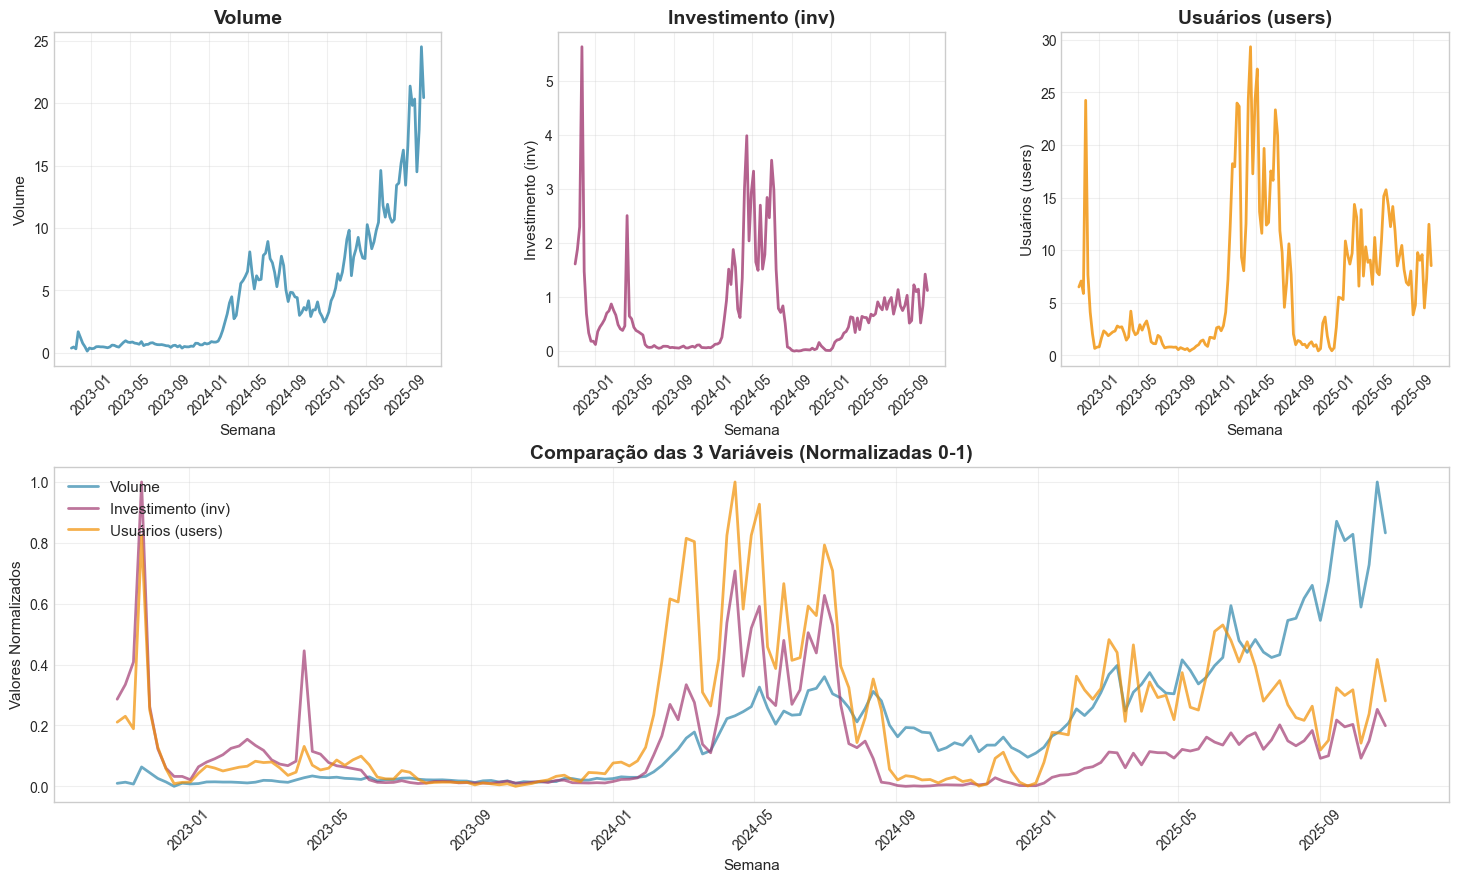

In [4]:
# Figura com 3 gráficos em cima e 1 embaixo
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Cores para cada variável
colors = {'volume': '#2E86AB', 'inv': '#A23B72', 'users': '#F18F01'}

# Gráficos individuais em cima (3 colunas)
variables = ['volume', 'inv', 'users']
titles = ['Volume', 'Investimento (inv)', 'Usuários (users)']

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(data.index, data[var], color=colors[var], linewidth=2, alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Semana', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Gráfico combinado embaixo (ocupando as 3 colunas)
ax_combined = fig.add_subplot(gs[1, :])

# Normalizar os dados para plotar juntos (escala 0-1)
data_normalized = (data - data.min()) / (data.max() - data.min())

for var, title in zip(variables, titles):
    ax_combined.plot(data.index, data_normalized[var],
                     label=title, color=colors[var], linewidth=2, alpha=0.7)

ax_combined.set_title('Comparação das 3 Variáveis (Normalizadas 0-1)',
                      fontsize=14, fontweight='bold')
ax_combined.set_xlabel('Semana', fontsize=11)
ax_combined.set_ylabel('Valores Normalizados', fontsize=11)
ax_combined.legend(loc='upper left', fontsize=11)
ax_combined.grid(True, alpha=0.3)
ax_combined.tick_params(axis='x', rotation=45)

plt.show()

Como podemos ver, parece haver uma relação forte entre as covariáveis `users` e `inv`, com ambas seguindo o mesmo padrão, principalmente nos picos ocorridos em 2022 e na metade de 2024. Por outro lado, nossa variável target `volume` ou não corresponde a isso ou corresponde de forma mais suave. Além disso, ao final da série, vemos uma força de crescimento muito maior nessa variável do que nas outras.

### 1.2. Autocorrelação da variável target `volume`

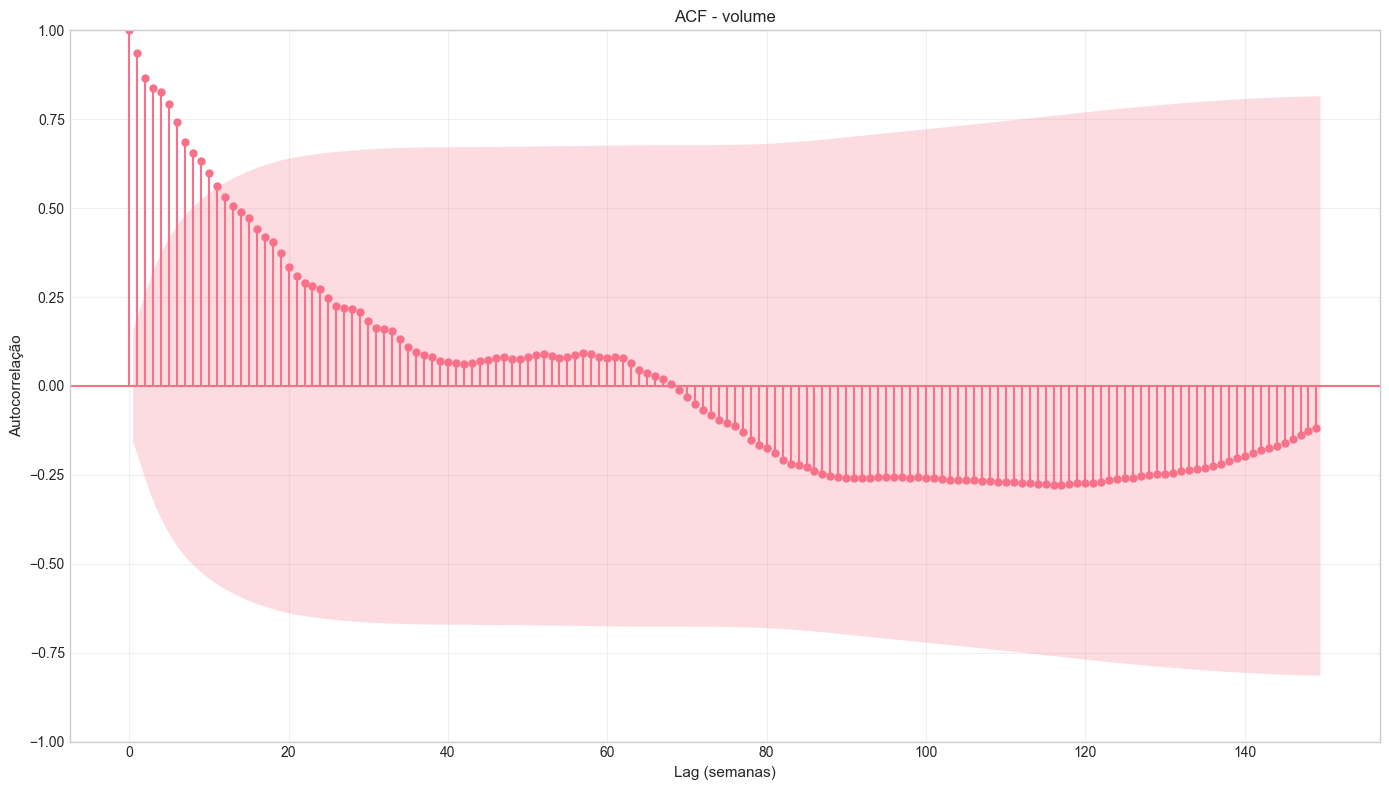

In [5]:
# Plotando a ACF da variável target
plot_acf(data["volume"], lags=149, alpha=0.05, title=f'ACF - volume')
plt.xlabel('Lag (semanas)', fontsize=11)
plt.ylabel('Autocorrelação', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ao analisar esse gráfico, vemos uma persistência significativa nos primeiros lags, com um decaimento suave característico de séries não-estacionárias com forte componente de tendência, sugerindo que a inércia da própria série é um componente preditivo essencial. Isso indica antecipadamente que os modelos baseados apenas em covariáveis externos (como o TSLM simples, que será analisado na seção 2) provavelmente deixarão autocorrelação residual, exigindo uma abordagem de regressão dinâmica para capturar essa estrutura de memória.

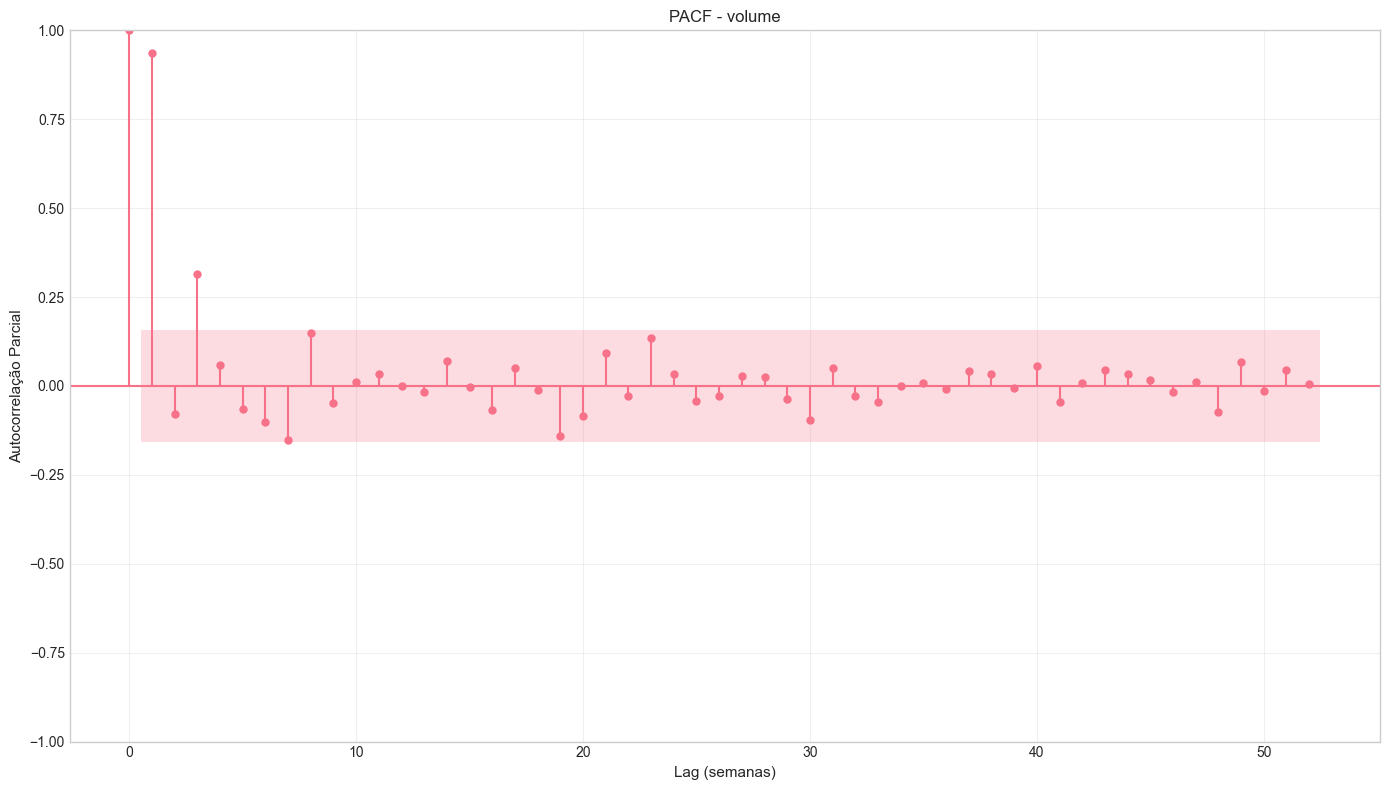

In [6]:
# Plotando a PACF da variável target
plot_pacf(data["volume"], lags=52, alpha=0.05, title=f'PACF - volume')
plt.xlabel('Lag (semanas)', fontsize=11)
plt.ylabel('Autocorrelação Parcial', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Já esse gráfico da PACF da target `volume` confirma a estrutura auto-regressiva dessa variável, com um corte de significância abrupto após o lag 1, o que sugere um processo gerador AR de ordem 1. Esses resultados serão utilizados para o ajuste dos modelos ARIMA na seção 4.

### 1.3. Teste de sazonalidade

A seguir, vamos realizar a decomposição STL da variável `volume` para verificar se existe alguma componente sazonal relevante. Para isso, faremos a decomposição com janelas de 4 semanas (mensal) e 52 semanas (anual).

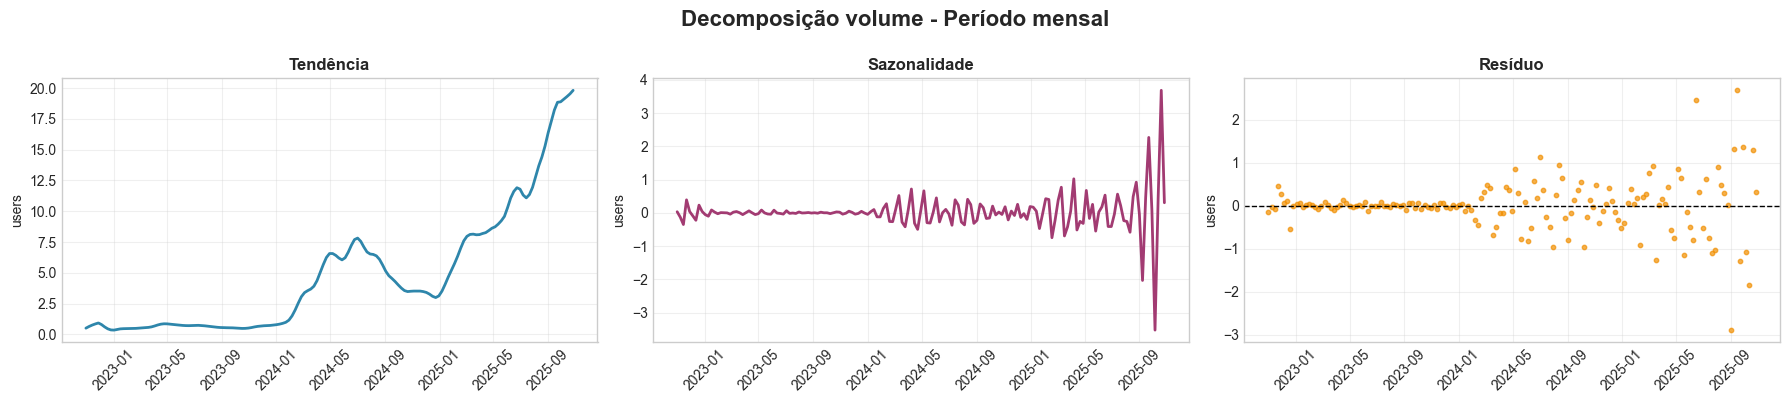

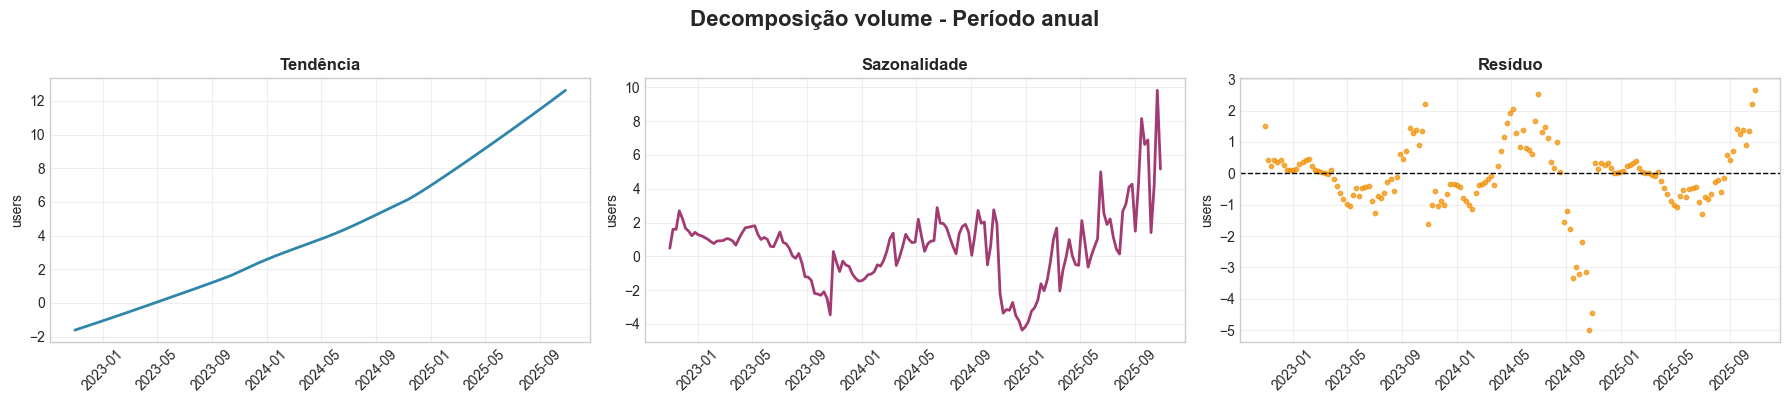

In [7]:
for period in [4, 52]:    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Decomposição mensal usando STL7
    decomp = STL(data["volume"], period=period).fit()

    # Tendência
    axes[0].plot(decomp.trend, color='#2E86AB', linewidth=2)
    axes[0].set_title(f'Tendência', fontsize=12, fontweight='bold')
    axes[0].set_ylabel(var, fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Sazonalidade
    axes[1].plot(decomp.seasonal, color='#A23B72', linewidth=2)
    axes[1].set_title(f'Sazonalidade', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(var, fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    # Resíduo (scatter plot)
    axes[2].scatter(decomp.resid.index, decomp.resid, color='#F18F01', alpha=0.7, s=10)
    axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[2].set_title(f'Resíduo', fontsize=12, fontweight='bold')
    axes[2].set_ylabel(var, fontsize=10)
    axes[2].grid(True, alpha=0.3)
    axes[2].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Decomposição volume - Período {"mensal" if period == 4 else "anual"}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

Como podemos ver, com período semanal, a componente sazonal apresenta baixa amplitude relativa, sendo irrelevante quando comparada com a tendência. E, com período anual, embora a sazonalidade agora possua impacto significativo, os resíduos possuem uma estrutura que claramente não é ruidosa.

No entanto, na decomposição mensal, observamos ruídos com amplitude maior no final da série, quando a variável `volume` apresenta valores maiores. Isso sugere fortemente uma heterocedasticidade dos dados. Dessa forma, vamos aplicar uma transformação $\log$ nessa variável e tentar novamente realizar a decomposição STL.

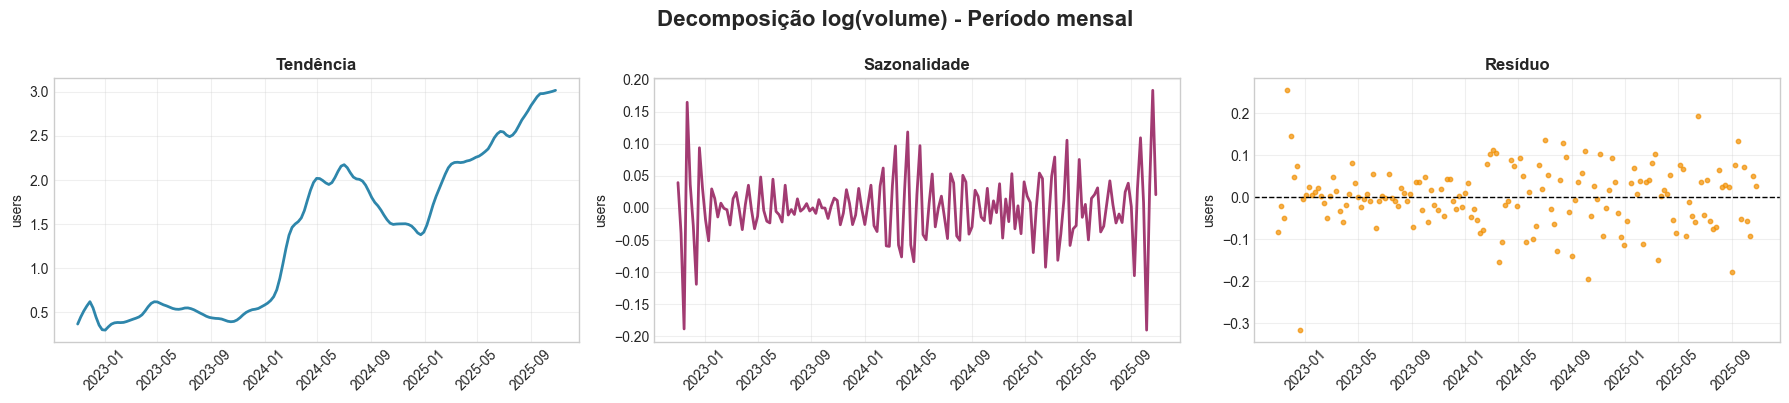

In [8]:
# Tranformação
data_log = data.copy()
data_log[f'volume_log'] = np.log1p(data["volume"])

# Decomposição mensal usando STL7
decomp = STL(data_log["volume_log"], period=4).fit()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Tendência
axes[0].plot(decomp.trend, color='#2E86AB', linewidth=2)
axes[0].set_title(f'Tendência', fontsize=12, fontweight='bold')
axes[0].set_ylabel(var, fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sazonalidade
axes[1].plot(decomp.seasonal, color='#A23B72', linewidth=2)
axes[1].set_title(f'Sazonalidade', fontsize=12, fontweight='bold')
axes[1].set_ylabel(var, fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Resíduo (scatter plot)
axes[2].scatter(decomp.resid.index, decomp.resid, color='#F18F01', alpha=0.7, s=10)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_title(f'Resíduo', fontsize=12, fontweight='bold')
axes[2].set_ylabel(var, fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(f'Decomposição log(volume) - Período mensal', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Agora, obtivemos um resíduo com estrutura razoavelmente aleatória, indicando o sucesso da aplicação da transformação $\log$. No entanto, a componente sazonal continua com uma amplitude descartável. Portanto, optaremos por não incluir componentes sazonais nos ajustes dos nossos modelos, mas utilizaremos a transformação logarítmica da variável target.

In [9]:
data_log[f'inv_log'] = np.log1p(data["inv"])
data_log[f'users_log'] = np.log1p(data["users"])

### 1.4. Correlações com as covariáveis

Em seguida, faremos gráficos de dispersão da variável target `volume` contra as covariáveis `inv` e `users`, tanto com a target original quanto com a versão transformada por $\log$, para avaliar a significância das covariáveis para explicar a `volume`.

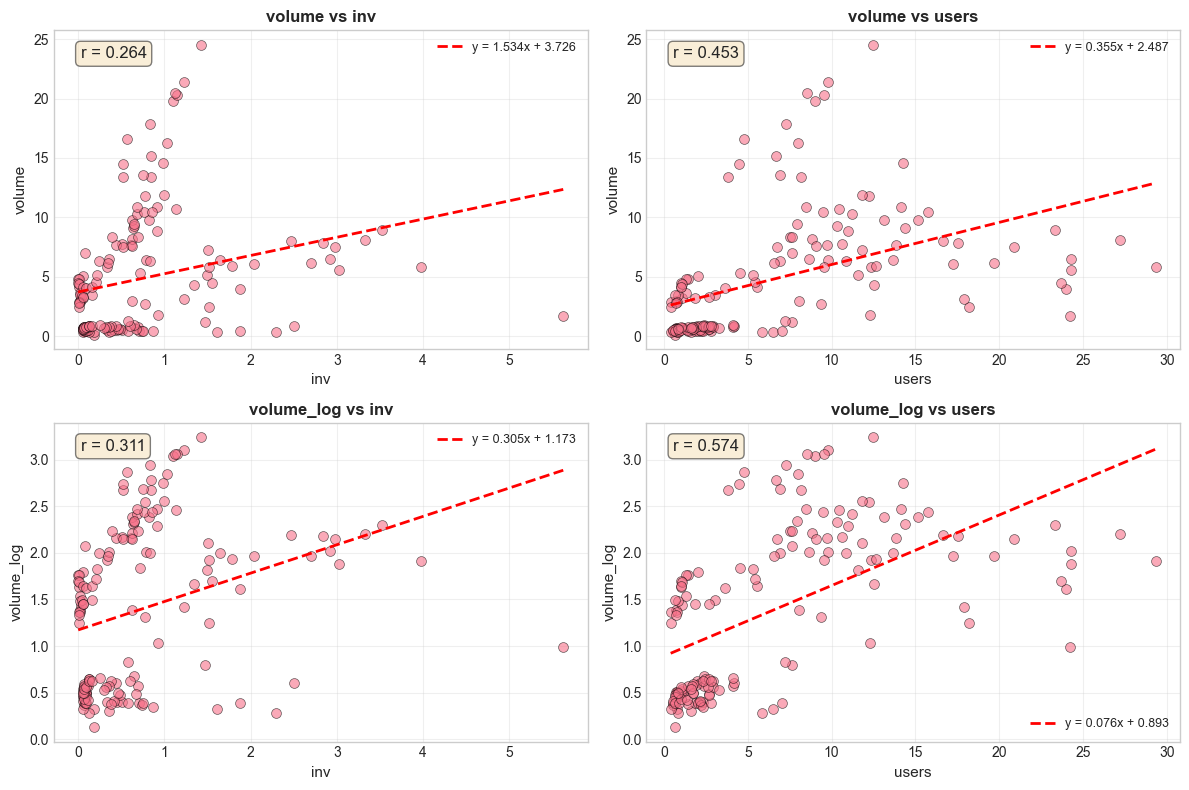

In [10]:
# Scatter plots com linha de tendência (volume original)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs = [('inv', 'volume'), ('users', 'volume'), ('inv', 'volume_log'), ('users', 'volume_log')]

for i, (var1, var2) in enumerate(pairs):
    ax = axes[i // 2, i % 2]
    
    # Scatter
    ax.scatter(data_log[var1], data_log[var2], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    # Linha de tendência
    z = np.polyfit(data_log[var1], data_log[var2], 1)
    p = np.poly1d(z)
    ax.plot(data_log[var1].sort_values(), p(data_log[var1].sort_values()),
            "r--", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

    # Correlação
    corr = data_log[var1].corr(data_log[var2])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_xlabel(var1, fontsize=11)
    ax.set_ylabel(var2, fontsize=11)
    ax.set_title(f'{var2} vs {var1}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Pode-se ver que ambas as variáveis possuem certa correlação com a variável target, indicando potencial preditivo. Entretanto, nas versões com a target original (linha superior), os pontos se distanciam consideravelmente da reta ajustada à medida que o valor das variáveis aumenta, indicando a presença de heterocedasticidade. Com isso, as versões com transformação logarítmica da `volume` apresentam uma correlação mais regular e significativa, mais uma vez reforçando a necessidade da utilização dessa transformação.

Além disso, os valores das covariáveis `inv` e `users` também aparentam ter uma distribuição assimétrica à direita, com uma grande concentração de pontos em valores baixos e uma escassez de registros com valores maiores. Isso sugere a aplicação de transformações logarítmicas também a essas covariáveis, o que será considerado no ajuste dos modelos TSLM na seção 2.

### 1.5. Correlação cruzada

Por fim, vamos analisar a correlação cruzada entre a variável `volume` já com transformação logarítmica e as covariáveis `inv` e `users`, com o objetivo de verificar o imediatismo do impacto dos valores dessas covariáveis na variável target ou a amplitude de seu lag.

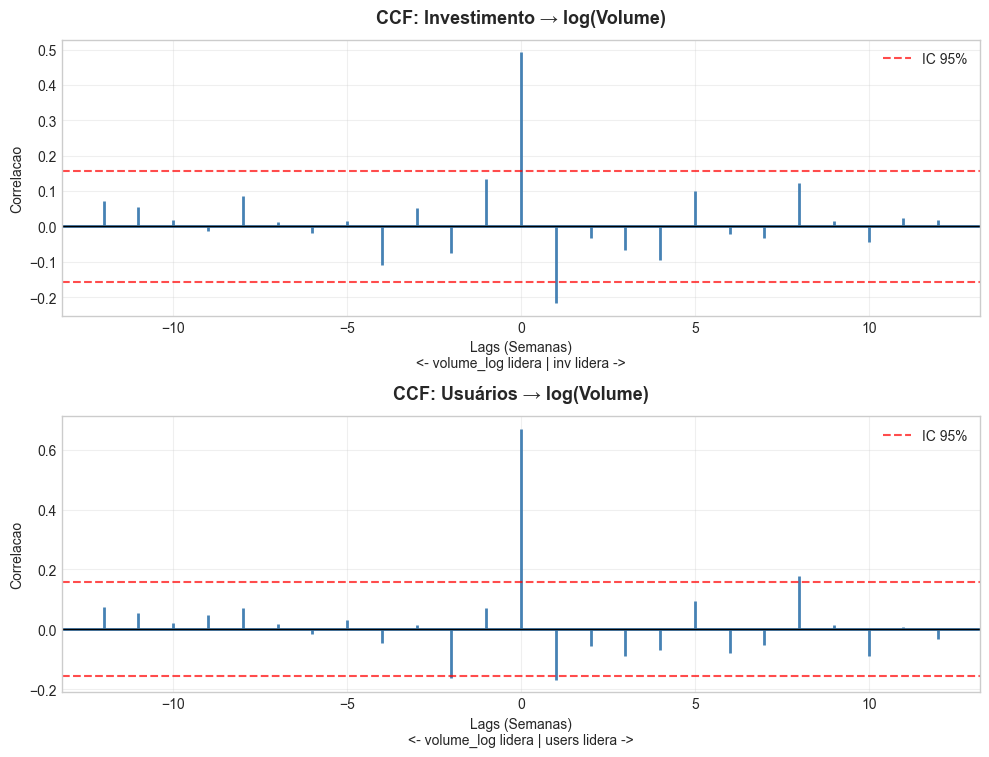

In [11]:
data["volume_log"] = np.log1p(data["volume"])

data_diff = data.diff().dropna()

max_lag = 12
pares = [
    ('inv', 'volume_log', 'Investimento → log(Volume)'),
    ('users', 'volume_log', 'Usuários → log(Volume)'),
]

fig, axes = plt.subplots(len(pares), 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.5)

for i, (var_x, var_y, titulo) in enumerate(pares):
    ax = axes[i]

    temp_df = data_diff[[var_x, var_y]].dropna()
    x = temp_df[var_x].values
    y = temp_df[var_y].values

    lags_plot, corrs_plot, _, _ = ax.xcorr(
        x, y,
        maxlags=max_lag,
        usevlines=True,
        normed=True,
        lw=2,
        color='steelblue'
    )

    n = len(x)
    limite = 1.96 / np.sqrt(n)
    ax.axhline(limite, color='red', linestyle='--', alpha=0.7, label='IC 95%')
    ax.axhline(-limite, color='red', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)

    ax.set_title(f"CCF: {titulo}", fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel("Correlacao")
    ax.set_xlabel(f"Lags (Semanas)\n<- {var_y} lidera | {var_x} lidera ->")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    sig_mask = np.abs(corrs_plot) > limite
    lags_sig = lags_plot[sig_mask]
    corrs_sig = corrs_plot[sig_mask]

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observando o lado direito desses gráficos, é possível ver que, tanto para `inv` quanto para `users`, existe uma alta correlação imediata entre elas e a `volume_log`, com valores significativos nos lags 0 e 1. No entanto, como não saberemos os valores dessas covariáveis na exata semana da qual queremos prever `volume`, então consideraremos aqui apenas o lag 1. Além disso, para a covariável `users`, podemos ver uma interação significativa entre ela e a variável target com 8 semanas de lag (2 meses), o que levanta a hipótese de um ciclo de maturação ou conversão tardia da base de usuários. Levaremos isso em consideração ao testar ajustes de modelos na próxima seção.

## 2. Modelagem TSLM

Nesta seção, realizaremos o ajuste de modelos lineares simples (sem autoregressão), utilizando as covariáveis disponíveis e algumas combinações e transformações derivadas dos resultados da seção anterior.

Inicialmente, vale ressaltar que todos os modelos ajustados a seguir serão baseados na transformação logarítmica da variável target `volume`, dadas as diversas evidências de heterocedasticidade apresentadas anteriormente. Além disso, com relação às covariáveis, sempre serão usadas suas versões com lag 1, dado que, em teoria, não conhecemos seus valores para a semana cujo valor de `volume` queremos prever.

Serão ajustados 3 modelos lineares para séries temporais:

- **Simples**: $\log$(`volume`) ~ `inv_lag_1` + `users_lag_1` + `users_lag_8`
- **Tendência**: $\log$(`volume`) ~ `inv_lag_1` + `users_lag_1` + `users_lag_8` + `trend`
- **Elasticidade**: $\log$(`volume`) ~ $\log$(`inv_lag_1`) + $\log$(`users_lag_1`) + $\log$(`users_lag_8`) + `trend`

Assim, iniciamos com um modelo simples, contendo apenas as covariáveis disponíveis e seus respectivos lags analisados na seção 1.5. Em seguida, adicionamos a componente de tendência, visível como relevante na seção 1.2. Por fim, testamos uma abordagem $\log$-$\log$, aplicando uma transformação logarítmica também nas covariáveis e em seus lags, como sugerido na seção 1.4.

### 2.1. Ajustes iniciais

In [12]:
# Criando as colunas derivadas
data["inv"] = data["inv"].shift(1)
data["users"] = data["users"].shift(1)
data["log_inv"] = np.log1p(data["inv"])
data["log_users"] = np.log1p(data["users"])
data["users_lag_8"] = data["users"].shift(7)
data["users_log_lag_8"] = np.log1p(data["users_lag_8"])
data["trend"] = np.arange(len(data))

data.dropna(inplace=True)

# Separando as covariáveis
X = data.drop('volume', axis=1)
y = data['volume']

# Aplicando o log na target
y_log = np.log1p(y)

data.head()

,volume,inv,users,volume_log,log_inv,log_users,users_lag_8,users_log_lag_8,trend
week,,,,,,,,,
2022-12-26,0.39,0.182806,0.655,0.329304,0.167889,0.503801,6.500,2.014903,8
2023-01-02,0.33,0.182695,0.778,0.285179,0.167795,0.575489,7.061,2.087038,9
2023-01-09,0.36,0.121898,0.808,0.307485,0.115022,0.592221,5.875,1.927892,10
2023-01-16,0.49,0.361241,1.641,0.398776,0.308397,0.971158,24.238,3.228351,11
2023-01-23,0.50,0.448260,2.323,0.405465,0.370363,1.200868,7.648,2.157328,12


In [13]:
log_models = {}

predictions = {}
models = {}

models_cols = {
    "Simples": ["inv", "users", "users_lag_8"],
    "Tendência": ["trend", "inv", "users", "users_lag_8"],
    "Elasticidade": ["trend", "log_inv", "log_users", "users_log_lag_8"],
}

results = {}

for model_name, cols in models_cols.items():
    X_model = sm.add_constant(X[cols])

    model = sm.OLS(y_log, X_model).fit()
    log_models[model_name] = model

    metrics = {}

    metrics["Adjusted R²"] = log_models[model_name].rsquared_adj
    metrics["AIC"] = log_models[model_name].aic
    metrics["BIC"] = log_models[model_name].bic

    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by="Adjusted R²", ascending=False))

,Adjusted R²,AIC,BIC
Elasticidade,0.966618,-122.155783,-107.136051
Tendência,0.945651,-49.532882,-34.513150
Simples,0.493994,281.935234,293.951019


Como podemos ver, a simples adição de uma componente de tendência melhora muito o desempenho do modelo, aumentando em aproximadamente 0.45 o valor do coeficiente R² ajustado, o que demonstra a presença de tendência determinística na variável target.

Em seguida, fica claro que o melhor modelo dentre esses é o modelo de elasticidade, com os logaritmos das covariáveis, que apresenta desempenho superior em todas as métricas consideradas. Isso mostra que a relação entre `volume` e as covariáveis `inv` e `users` não é linear, com o modelo $\log$-$\log$ se ajustando melhor.

### 2.2. Análises de significância

A seguir, vamos analisar a significância das variáveis dos dois melhores modelos.

In [14]:
log_models["Elasticidade"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1072.
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          4.85e-106
Time:                        22:07:25   Log-Likelihood:                 66.078
No. Observations:                 149   AIC:                            -122.2
Df Residuals:                     144   BIC:                            -107.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3996      0.033    -11.971      0.000      -0.466      -0.334
trend               0.0155      0.000     37.616      0.000       0.015       0.016
log_inv             0.4035      0.074      5.436      0.000       0.257       0.550
log_users           0.0626      0.035      1.771      0.079      -0.007       0.133
users_log_lag_8     0.1811      0.020      9.015      0.000       0.141       0.221
==============================================================================
Omnibus:                        2.576   Durbin-Watson:                   0.948
Prob(Omnibus):                  0.276   Jarque-Bera (JB):                2.553
Skew:                           0.269   Prob(JB):                        0.279
Kurtosis:                       2.650   Cond. No.                         578.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

No ajuste do modelo de elasticidade, quase todas as covariáveis mostraram-se fortemente significativas, com apenas `log_users` apresentando-se no limite da significância. Mais adiante, vamos tentar ajustar um modelo sem essa covariável para comparar seu desempenho com o do modelo original.

In [15]:
log_models["Tendência"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     644.8
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           8.26e-91
Time:                        22:07:25   Log-Likelihood:                 29.766
No. Observations:                 149   AIC:                            -49.53
Df Residuals:                     144   BIC:                            -34.51
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2092      0.038     -5.573      0.000      -0.283      -0.135
trend           0.0164      0.000     34.727      0.000       0.016       0.017
inv             0.1790      0.049      3.684      0.000       0.083       0.275
users           0.0083      0.006      1.422      0.157      -0.003       0.020
users_lag_8     0.0199      0.003      6.239      0.000       0.014       0.026
==============================================================================
Omnibus:                        6.765   Durbin-Watson:                   0.734
Prob(Omnibus):                  0.034   Jarque-Bera (JB):                3.402
Skew:                           0.095   Prob(JB):                        0.182
Kurtosis:                       2.285   Cond. No.                         287.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Já no modelo de tendência, com as covariáveis originais, novamente, a variável relacionada a `users` é a única com insignificância estatística.

### 2.3. Testes de filtragem de covariáveis

Por fim, ajustamos dois novos modelos: o modelo de elasticidade sem a covariável `log_users` e o modelo de tendência sem a covariável `users`. Vamos avaliar como a remoção dessas covariáveis, que não se mostraram significantes nos ajustes originais, afeta o desempenho desses modelos.

In [16]:
log_models = {}

predictions = {}
models = {}

models_cols.update({
    "Elasticidade (sem log_users)": ["trend", "log_inv", "users_log_lag_8"],
    "Tendência (sem users)": ["trend", "inv", "users_lag_8"],
})

results = {}

for model_name, cols in models_cols.items():
    X_model = sm.add_constant(X[cols])

    model = sm.OLS(y_log, X_model).fit()
    log_models[model_name] = model

    metrics = {}

    metrics["Adjusted R²"] = log_models[model_name].rsquared_adj
    metrics["AIC"] = log_models[model_name].aic
    metrics["BIC"] = log_models[model_name].bic

    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by="Adjusted R²", ascending=False))

,Adjusted R²,AIC,BIC
Elasticidade,0.966618,-122.155783,-107.136051
Elasticidade (sem log_users),0.966126,-120.946180,-108.930395
Tendência,0.945651,-49.532882,-34.513150
Tendência (sem users),0.945268,-49.455646,-37.439861
Simples,0.493994,281.935234,293.951019


Como podemos observar, em ambos os casos, a remoção dessas covariáveis resultou em leves pioras do ajuste dos modelos.

Com relação ao modelo de tendência, valeria a pena descartar a covariável `users`, dado que seu nível de insignificância estatística é bem considerável (p-valor = 0.157) e o modelo consegue performar quase que da mesma forma sem sua inclusão.

Por outro lado, mesmo que a remoção de `log_users` tenha reduzido levemente a qualidade do ajuste, dado que ela ainda encontra-se no limite da significância (p-valor = 0.079, muito próximo do limite usual 0.05), ainda vale a pena mantê-la. Isso é apoiado pelo fato de o coeficiente AIC do modelo de elasticidade original é melhor (menor) que o do modelo sem a covariável, indicando que, matematicamente, a informação ganha ao incluí-la compensa a penalidade de adicionar mais um parâmetro, o que não ocorre na comparação dos modelos de tendência.

Portanto, para as próximas análises, o modelo TSLM a ser considerado será o modelo de `Elasticidade` (com tendência).

## 3. Diagnóstico de resíduos

Conforme indicado pela análise de modelagem TSLM anterior, o modelo que apresentou o melhor desempenho foi o modelo de elasticidade com tendência (Log Covars + Trend). O modelo selecionado utiliza a transformação logarítmica na variável target e nas covariáveis, além de incluir um componente de tendência linear e o lag de 8 semanas da variável users. A especificação é: 

$$
    \log(volume)∼trend+\log(inv_{lag1})+\log(users_{lag1})+\log(users_{lag8}​)
$$

Nesta parte do trabalho, vamos realizar o diagnóstico dos resíduos deste modelo específico para verificar se as premissas de Mínimos Quadrados Ordinários (OLS) são satisfeitas:

- **Normalidade**: Os resíduos seguem uma distribuição normal?
  
- **Homocedasticidade**: A variância dos resíduos é constante?
  
- **Independência (ausência de autocorrelação)**: Restou alguma estrutura temporal nos resíduos que o TSLM não capturou? (Isso motivará o uso de ARIMA na próxima seção).

In [17]:
# modelos analisados
cols_selected = ["trend", "log_inv", "log_users", "users_log_lag_8"]

# extraindo os resíduos 
X_final = sm.add_constant(X[cols_selected])
model_final = sm.OLS(y_log, X_final).fit()
residuals = model_final.resid

### 3.1. Visualização e análise iniciais

c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


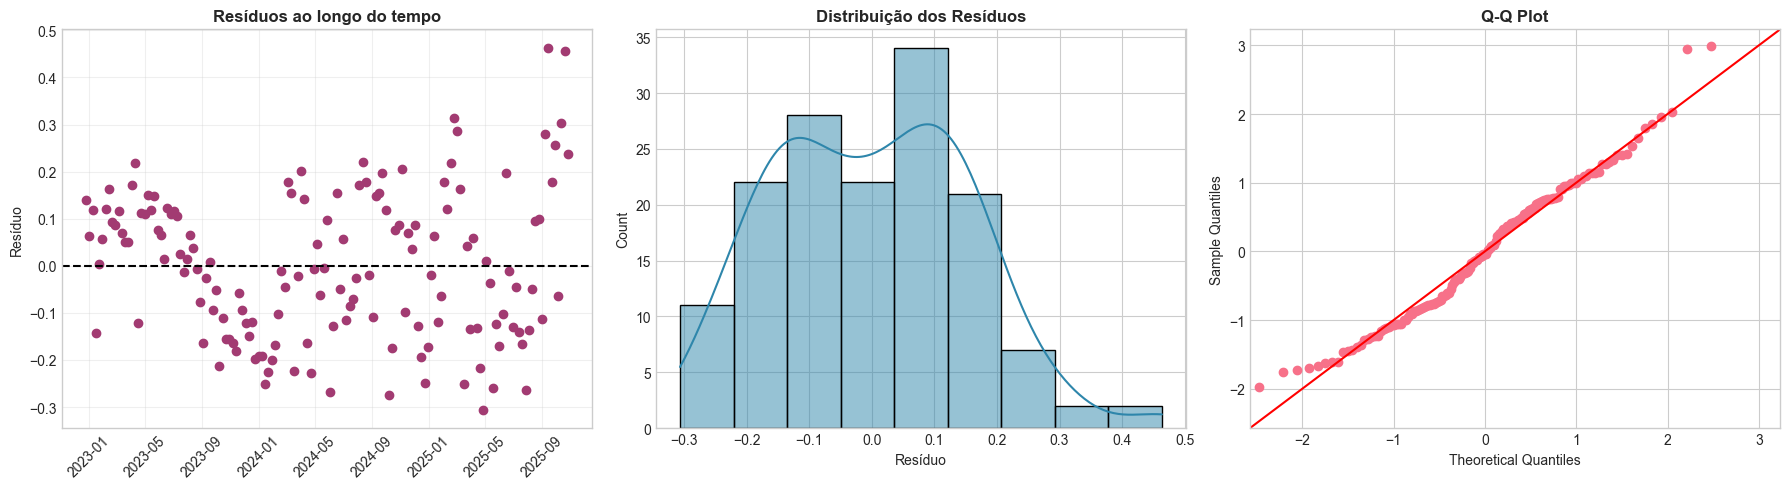

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# resíduos no tempo
axes[0].scatter(residuals.index, residuals, color='#A23B72')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Resíduos ao longo do tempo', fontweight='bold')
axes[0].set_ylabel('Resíduo')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# histograma
sns.histplot(residuals, kde=True, ax=axes[1], color='#2E86AB')
axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1].set_xlabel('Resíduo')

# QQ plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[2])
axes[2].set_title('Q-Q Plot', fontweight='bold')

plt.tight_layout()
plt.show()

Os gráficos acima parecem apontar para a normalidade dos resíduos, mas, para não restar dúvidas, vamos usar o [**Teste de Jaque-Bera**](https://en-wikipedia-org.translate.goog/wiki/Jarque%E2%80%93Bera_test?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc). Ele vai medir principalmente duas coisas: assimetria (skewness), ou seja, se a curva está torta para algum lado; e curtose (kurtosis), isto é, se a cauda é mais pesada/leve do que deveria ser. A hipótese nula é que os dados são normalmente distribuídos. Caso o p-valor seja maior que 0.05, falhamos em recusar tal hipótese. 

In [19]:
jb_test = stats.jarque_bera(residuals)
print(f"Teste Jarque-Bera: Estatística={jb_test.statistic:.4f}, p-valor={jb_test.pvalue:.4f}")

if jb_test.pvalue > 0.05:
    print("Não rejeitamos a hipótese nula. Os resíduos são normais.")
else:
    print("Rejeitamos a hipótese nula. Os resíduos não seguem uma distribuição normal.")

Teste Jarque-Bera: Estatística=2.5534, p-valor=0.2790
Não rejeitamos a hipótese nula. Os resíduos são normais.


### 3.2. Análise de autocorrelação dos resíduos

Um dos pontos críticos em séries temporais é garantir que o modelo capturou toda a dependência temporal. Se os resíduos apresentarem autocorrelação significativa, então o modelo TSLM deixou alguma informação que poderia ser modelada por uma estrutura AR (Auto-Regressiva) ou MA (Média Móvel).

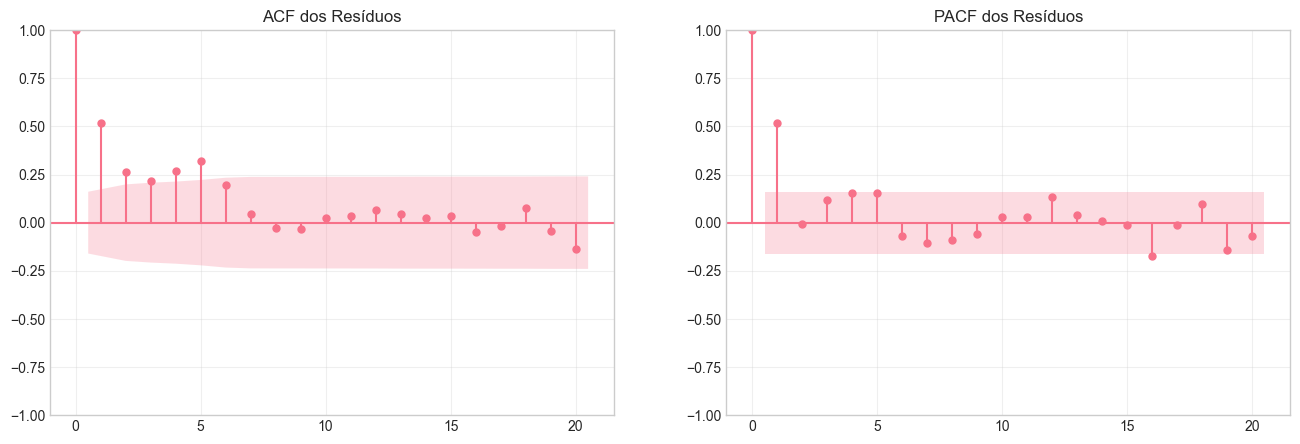

In [20]:
# plotagem ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(residuals, lags=20, ax=axes[0], title='ACF dos Resíduos', alpha=0.05)
axes[0].grid(True, alpha=0.3)

plot_pacf(residuals, lags=20, ax=axes[1], title='PACF dos Resíduos', alpha=0.05)
axes[1].grid(True, alpha=0.3)

plt.show()

Como podemos ver, os resíduos apresentam correlação estatisticamente significativa no lag 1, o que indica que a hipótese de independência dos resíduos foi violada e que o TSLM não foi capaz de capturar totalmente a dinâmica de curto prazo da série. Isso sugere que a informação contida no erro passado pode ser utilizada para refinar as previsões futuras, o que nos levará mais adiante ao ajuste do modelo ARIMA com covariáveis.

De maneira complementar, vamos usar o [**Teste de Ljung-Box**](https://en-wikipedia-org.translate.goog/wiki/Ljung%E2%80%93Box_test?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc). Ele serve para verificar se a série temporal tem autocorrelação, ou seja, se os valores do passado influenciam ou estão relacionados com os valores do futuro. A ideia não é analisar só um lag específico, mas vários lags ao mesmo tempo, testando se há algum padrão repetitivo na série. A hipótese nula é que não existe dependência temporal.

In [21]:
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)

lb_test["Tem correlação?"] = np.where(lb_test["lb_pvalue"] < 0.05, "Sim (p-valor < 0.05)", "Não (p-valor >= 0.05)")

print("Teste de Ljung-Box (lags 1 ao 10):")
display(lb_test)

p_val_lb = lb_test['lb_pvalue']
if np.any(p_val_lb < 0.05):
    print(f">> Resíduos NÃO são ruído branco (há estrutura temporal não capturada).")
else:
    print(f">> Resíduos se comportam como ruído branco (sem autocorrelação significativa).")

Teste de Ljung-Box (lags 1 ao 10):


,lb_stat,lb_pvalue,Tem correlação?
1,40.393495,2.076312e-10,Sim (p-valor < 0.05)
2,50.848254,9.087449e-12,Sim (p-valor < 0.05)
3,58.219926,1.410768e-12,Sim (p-valor < 0.05)
4,69.327422,3.147517e-14,Sim (p-valor < 0.05)
5,85.361418,6.322469e-17,Sim (p-valor < 0.05)
6,91.495243,1.481659e-17,Sim (p-valor < 0.05)
7,91.835308,5.192220e-17,Sim (p-valor < 0.05)
8,91.968395,1.851906e-16,Sim (p-valor < 0.05)
9,92.121901,6.102770e-16,Sim (p-valor < 0.05)
10,92.227733,1.934605e-15,Sim (p-valor < 0.05)


>> Resíduos NÃO são ruído branco (há estrutura temporal não capturada).


A presença de correlação significativa nos primeiros lags confirma o resultado do teste de Ljung-Box. Isso indica que, embora o modelo de regressão (TSLM) tenha capturado bem a tendência e a relação com as covariáveis, ele não capturou a dinâmica inercial da série. O resíduo de hoje ainda depende do resíduo de ontem.

### 3.3. Resíduos vs covariáveis

Por fim, verificamos se os resíduos guardam alguma relação com as variáveis explicativas (`inv` e `users`). Idealmente, não deve haver padrão visível; uma dispersão aleatória indica que a relação linear (ou log-log) capturou bem a influência dessas variáveis.

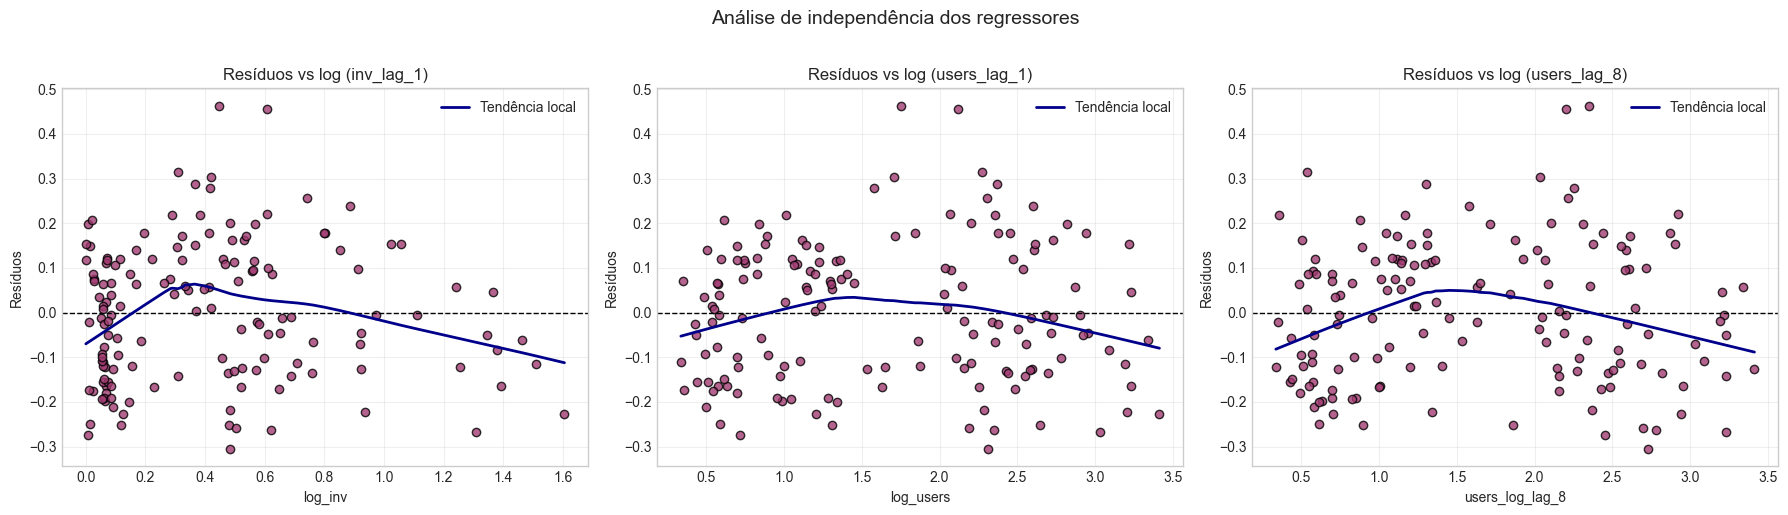

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

covars_check = ['log_inv', 'log_users', 'users_log_lag_8']
titles = ['log (inv_lag_1)', 'log (users_lag_1)', 'log (users_lag_8)']

for i, col in enumerate(covars_check):
    # scatter
    axes[i].scatter(X[col], residuals, alpha=0.8, color='#A23B72', edgecolors='black')
    
    axes[i].axhline(0, color='black', linestyle='--', lw=1)
    
    # linha de tendência
    lowess = sm.nonparametric.lowess
    z = lowess(residuals, X[col], frac=0.7)
    axes[i].plot(z[:,0], z[:,1], color='darkblue', lw=2, label='Tendência local')
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Resíduos')
    axes[i].set_title(f'Resíduos vs {titles[i]}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.suptitle('Análise de independência dos regressores', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Esses gráficos validam a escolha funcional do modelo (transformação $\log$-$\log$). Eles sugerem que a relação entre a variável target e as covariáveis foi bem capturada e que os resíduos são independentes dos regressores. O erro do modelo não está correlacionado com o valor do investimento ou com o número de usuários, o que é um excelente sinal de que as variáveis exógenas foram bem utilizadas.

Em resumo, o diagnóstico aponta que o modelo TSLM satisfaz as premissas de normalidade e de forma funcional correta (resíduos independentes das covariáveis). No entanto, a premissa de independência temporal falha. Portanto, para obter um modelo robusto e previsões confiáveis, é imperativo modelar essa autocorrelação residual utilizando a metodologia ARIMA na próxima etapa.

## 4. ARIMA com covariáveis

### 4.1. Preparação dos dados

Conforme realizado na seção anterior, utilizamos a mesma transformação logarítmica na variável target volume e mantivemos as mesmas covariáveis em suas versões transformadas e com lags apropriados.

In [26]:
# Covariáveis originais
print("Preparando covariáveis originais:")
exog_originais = data[["inv", "users", "users_lag_8"]]
print(f"exog_originais: {exog_originais.shape}")

# Covariáveis em log
print(f"\nPreparando covariáveis em log:")
exog_log = data[["log_inv", "log_users", "users_log_lag_8"]]
print(f"exog_log: {exog_log.shape}")

# Série resposta (target) 
print(f"\ny_log (volume em log): {y_log.shape}")

Preparando covariáveis originais:
exog_originais: (149, 3)

Preparando covariáveis em log:
exog_log: (149, 3)

y_log (volume em log): (149,)


### 4.2. Análise dos resíduos do melhor modelo TSLM para identificar ordem ARIMA

Antes de ajustar o ARIMA, analisaremos a autocorrelação nos resíduos do Modelo TSLM `Elasticidade` para confirmar a necessidade de incorporar uma estrutura temporal.

In [28]:
melhor_tslm = log_models["Elasticidade"]
print(f"Modelo TSLM: Elasticidade")
print(f"R² ajustado: {melhor_tslm.rsquared_adj:.4f}")
print(f"AIC: {melhor_tslm.aic:.2f}")
print(f"BIC: {melhor_tslm.bic:.2f}")

Modelo TSLM: Elasticidade
R² ajustado: 0.9666
AIC: -122.16
BIC: -107.14


A análise da ACF/PACF dos resíduos do TSLM (realizada anteriormente) sugeriu a presença de autocorrelação significativa, com o PACF apresentando corte no lag 1, indicando que um processo AR(1) pode ser apropriado para capturar essa dependência temporal. Com base nessas observações, testaremos algumas combinações de (p, d, q).

### 4.3. Função para ajuste de modelos ARIMA

Definimos uma função especializada para ajustar modelos SARIMAX (ARIMA com covariáveis exógenas), configurada para lidar adequadamente com diferentes especificações de ordem.

In [29]:
def ajustar_sarimax(y, exog, ordem, nome_modelo):
    """Ajusta um modelo SARIMAX (ARIMA com covariáveis) e retorna métricas"""
    try:
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        
        p, d, q = ordem
        trend = 'n'  # Sem constante, pois temos covariáveis exógenas
        
        modelo = SARIMAX(
            endog=y,
            exog=exog,
            order=ordem,
            seasonal_order=(0, 0, 0, 0),
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
            initialization='approximate_diffuse'
        )
        
        if q > 0:
            resultado = modelo.fit(disp=False, maxiter=300, method='bfgs')
        else:
            resultado = modelo.fit(disp=False, maxiter=200)
        
        return resultado
        
    except Exception as e:
        print(f"{nome_modelo} falhou: {str(e)[:100]}...")
        return None

In [ ]:
def ajustar_sarimax(y, exog, ordem, nome_modelo):
    """Ajusta um modelo SARIMAX (ARIMA com covariáveis) e retorna métricas"""
    try:
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        
        p, d, q = ordem
        trend = 'n' if d > 0 else 'c'
        
        modelo = SARIMAX(
            endog=y,
            exog=exog,
            order=ordem,
            seasonal_order=(0, 0, 0, 0),
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
            initialization='approximate_diffuse'
        )
        
        if q > 0:
            resultado = modelo.fit(disp=False, maxiter=300, method='bfgs')
        else:
            resultado = modelo.fit(disp=False, maxiter=200)
        
        return resultado
        
    except Exception as e:
        print(f"{nome_modelo} falhou: {str(e)[:100]}...")
        return None

### 4.4. Teste 1: ARIMA com covariáveis originais

Testamos modelos ARIMA utilizando as covariáveis em sua forma original, sem transformação logarítmica, replicando a estrutura testada nos modelos TSLM lineares.

In [ ]:
print("TESTE 1: ARIMA com covariáveis ORIGINAIS")

ordens_testar = [(1, 0, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1)]
teste1_resultados = []
teste1_modelos = {}

for ordem in ordens_testar:
    nome = f"ARIMA{ordem} - Originais"
    modelo = ajustar_sarimax(y_log, exog_originais, ordem, nome)
    
    if modelo is not None:
        teste1_modelos[nome] = modelo
        teste1_resultados.append({
            'Modelo': nome,
            'AIC': modelo.aic,
            'BIC': modelo.bic,
            'LLF': modelo.llf,
            'Ordem': str(ordem),
            'Tipo': 'Originais',
            'Resultado': modelo
        })
        print(f"{nome}: AIC = {modelo.aic:.2f}")

TESTE 1: ARIMA com covariáveis ORIGINAIS
✓ ARIMA(1, 0, 0) - Originais: AIC = -158.28
✓ ARIMA(1, 1, 0) - Originais: AIC = -156.03


c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, fr

✓ ARIMA(0, 1, 1) - Originais: AIC = -139.21
✓ ARIMA(1, 1, 1) - Originais: AIC = -138.62


c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


### 4.5. Teste 2: ARIMA com covariáveis em log (log-log)

Testamos modelos ARIMA utilizando as covariáveis transformadas em log.

In [31]:
print("TESTE 2: ARIMA com covariáveis EM LOG (modelo log-log)")

teste2_resultados = []
teste2_modelos = {}

for ordem in ordens_testar:
    nome = f"ARIMA{ordem} - Log-log"
    modelo = ajustar_sarimax(y_log, exog_log, ordem, nome)
    
    if modelo is not None:
        teste2_modelos[nome] = modelo
        teste2_resultados.append({
            'Modelo': nome,
            'AIC': modelo.aic,
            'BIC': modelo.bic,
            'LLF': modelo.llf,
            'Ordem': str(ordem),
            'Tipo': 'Log-log',
            'Resultado': modelo
        })
        print(f"{nome}: AIC = {modelo.aic:.2f}")

TESTE 2: ARIMA com covariáveis EM LOG (modelo log-log)
ARIMA(1, 0, 0) - Log-log: AIC = -161.43
ARIMA(1, 1, 0) - Log-log: AIC = -159.27
ARIMA(0, 1, 1) - Log-log: AIC = -144.48


c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\livia_yrabu3q\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\liv

ARIMA(1, 1, 1) - Log-log: AIC = -144.52


### 4.6. Comparação de todos os modelos

Combinamos os resultados de ambos os testes para identificar o melhor modelo ARIMA considerando todas as especificações testadas.

In [33]:
print("SELEÇÃO DO MELHOR MODELO E FILTRAGEM DE COVARIÁVEIS")

# Combinar todos os resultados
todos_resultados = teste1_resultados + teste2_resultados
todos_modelos = {**teste1_modelos, **teste2_modelos}

if todos_resultados:
    df_comparacao = pd.DataFrame(todos_resultados)
    df_comparacao = df_comparacao.sort_values('AIC')
    
    print("\nMELHOR MODELO INICIAL (ordenado por AIC):")
    print(df_comparacao[['Modelo', 'AIC', 'BIC', 'Tipo']].to_string(index=False))
    
    melhor_info = df_comparacao.iloc[0]
    melhor_modelo = melhor_info['Resultado']
    
    print(f"\nMelhor modelo inicial: {melhor_info['Modelo']}")
    print(f"   AIC: {melhor_info['AIC']:.2f}")
    print(f"   BIC: {melhor_info['BIC']:.2f}")
    print(f"   Tipo: {melhor_info['Tipo']}")
    
    # Analisar significância das covariáveis no melhor modelo
    print("\nAnálise de significância das covariáveis:")
    coef_df = pd.DataFrame({
        'Parâmetro': melhor_modelo.params.index,
        'Coeficiente': melhor_modelo.params.values,
        'P>|z|': melhor_modelo.pvalues.values
    })
    
    # Filtrar apenas covariáveis exógenas (não incluir parâmetros AR/MA)
    covars_coef = coef_df[coef_df['Parâmetro'].str.contains('exog')]
    
    if not covars_coef.empty:
        print("\nCovariáveis exógenas no modelo:")
        for _, row in covars_coef.iterrows():
            param = row['Parâmetro']
            coef = row['Coeficiente']
            p_val = row['P>|z|']
            var_name = param.split('.')[1] if '.' in param else param
            significancia = "✓" if p_val < 0.05 else "✗"
            print(f"  {significancia} {var_name}: {coef:.4f} (p={p_val:.4f})")
        
        # Identificar covariáveis não significativas (p ≥ 0.05)
        covars_nao_sig = covars_coef[covars_coef['P>|z|'] >= 0.05]
        
        if not covars_nao_sig.empty:
            print(f"\nCovariáveis não significativas encontradas: {len(covars_nao_sig)}")
            
            # Testar modelo sem as covariáveis não significativas
            covars_remover = []
            for _, row in covars_nao_sig.iterrows():
                param = row['Parâmetro']
                var_name = param.split('.')[1] if '.' in param else param
                covars_remover.append(var_name)
            
            print(f"  Removendo: {covars_remover}")
            
            # Criar novo conjunto de covariáveis
            if melhor_info['Tipo'] == 'Originais':
                cols_originais = ["inv", "users", "users_lag_8"]
                cols_filtradas = [col for col in cols_originais if col not in covars_remover]
                exog_filtrado = data[cols_filtradas]
            else:  # Log-log
                cols_log = ["log_inv", "log_users", "users_log_lag_8"]
                cols_filtradas = [col for col in cols_log if col not in covars_remover]
                exog_filtrado = data[cols_filtradas]
            
            # Ajustar modelo filtrado
            ordem_melhor = eval(melhor_info['Ordem'])
            nome_filtrado = f"{melhor_info['Modelo']} - sem {len(covars_remover)} vars"
            modelo_filtrado = ajustar_sarimax(y_log, exog_filtrado, ordem_melhor, nome_filtrado)
            
            if modelo_filtrado is not None:
                print(f"\nComparação com modelo filtrado:")
                print(f"  • Modelo original: AIC = {melhor_info['AIC']:.2f}")
                print(f"  • Modelo filtrado: AIC = {modelo_filtrado.aic:.2f}")
                
                dif_aic = modelo_filtrado.aic - melhor_info['AIC']
                
                if dif_aic < 0:
                    print(f"  Modelo filtrado é melhor (ΔAIC = {dif_aic:.2f})")
                    melhor_modelo = modelo_filtrado
                    melhor_info['Modelo'] = nome_filtrado
                    melhor_info['AIC'] = modelo_filtrado.aic
                    melhor_info['BIC'] = modelo_filtrado.bic
                else:
                    print(f"  Modelo original é melhor (ΔAIC = {dif_aic:.2f})")
        else:
            print("\nTodas as covariáveis são significativas (p < 0.05)")
    else:
        print("Nenhuma covariável exógena encontrada no modelo.")
        
else:
    print("Nenhum modelo foi ajustado com sucesso.")
    melhor_modelo = None

SELEÇÃO DO MELHOR MODELO E FILTRAGEM DE COVARIÁVEIS

MELHOR MODELO INICIAL (ordenado por AIC):
                    Modelo         AIC         BIC      Tipo
  ARIMA(1, 0, 0) - Log-log -161.430935 -146.411203   Log-log
  ARIMA(1, 1, 0) - Log-log -159.272360 -144.252628   Log-log
ARIMA(1, 0, 0) - Originais -158.283359 -143.263628 Originais
ARIMA(1, 1, 0) - Originais -156.025286 -141.005554 Originais
  ARIMA(1, 1, 1) - Log-log -144.515946 -126.492268   Log-log
  ARIMA(0, 1, 1) - Log-log -144.475467 -129.455735   Log-log
ARIMA(0, 1, 1) - Originais -139.210855 -124.191124 Originais
ARIMA(1, 1, 1) - Originais -138.623981 -120.600303 Originais

Melhor modelo inicial: ARIMA(1, 0, 0) - Log-log
   AIC: -161.43
   BIC: -146.41
   Tipo: Log-log

Análise de significância das covariáveis:
Nenhuma covariável exógena encontrada no modelo.


### 4.7. Diagnóstico do melhor modelo ARIMA
Realizamos diagnóstico detalhado do melhor modelo identificado para avaliar a qualidade do ajuste e verificar premissas.


DIAGNÓSTICO DO MODELO ARIMA FINAL

Resumo do modelo ARIMA(1, 0, 0) - Log-log:
                               SARIMAX Results                                
Dep. Variable:                 volume   No. Observations:                  149
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  85.715
Date:                Mon, 01 Dec 2025   AIC                           -161.431
Time:                        22:47:14   BIC                           -146.411
Sample:                    12-26-2022   HQIC                          -155.329
                         - 10-27-2025                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
log_inv             0.1075      0.097      1.103      0.270      -0.083       0.298
log_users           0.0019      0.048

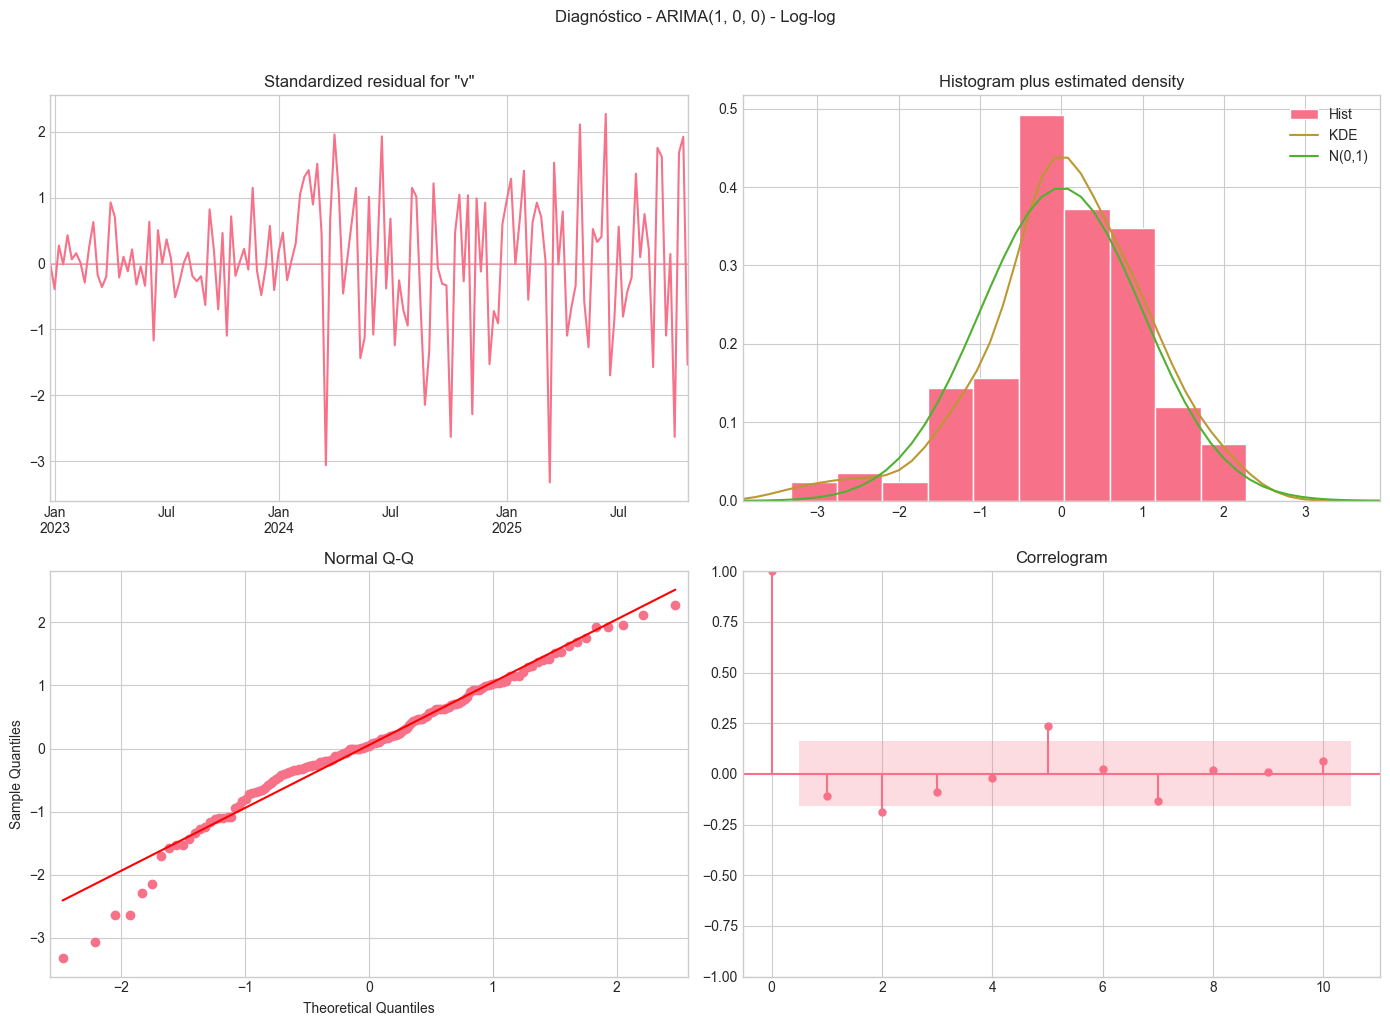


Análise estatística dos resíduos:
  • Média: 0.008509
  • Desvio padrão: 0.129399
  • Assimetria: -0.5873
  • Curtose: 1.0165

Teste de autocorrelação (Ljung-Box):
  • Lag 10: p-valor = 0.0279
  Resíduos apresentam autocorrelação significativa

Interpretação dos coeficientes significativos:
  • AR(L1): 1.0084 (persistência temporal)


In [34]:
if melhor_modelo is not None:
    print("\n" + "="*80)
    print("DIAGNÓSTICO DO MODELO ARIMA FINAL")
    print("="*80)
    
    print(f"\nResumo do modelo {melhor_info['Modelo']}:")
    print(melhor_modelo.summary())
    
    print("\nDiagnóstico gráfico dos resíduos:")
    fig = melhor_modelo.plot_diagnostics(figsize=(14, 10))
    plt.suptitle(f'Diagnóstico - {melhor_info["Modelo"]}', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Análise detalhada dos resíduos
    resíduos = melhor_modelo.resid
    
    print("\nAnálise estatística dos resíduos:")
    print(f"  • Média: {resíduos.mean():.6f}")
    print(f"  • Desvio padrão: {resíduos.std():.6f}")
    print(f"  • Assimetria: {resíduos.skew():.4f}")
    print(f"  • Curtose: {resíduos.kurtosis():.4f}")
    
    # Teste de autocorrelação nos resíduos
    print("\nTeste de autocorrelação (Ljung-Box):")
    lb_test = acorr_ljungbox(resíduos.dropna(), lags=[10], return_df=True)
    print(f"  • Lag 10: p-valor = {lb_test.iloc[0]['lb_pvalue']:.4f}")
    
    if lb_test.iloc[0]['lb_pvalue'] > 0.05:
        print("  Resíduos não apresentam autocorrelação significativa")
    else:
        print("  Resíduos apresentam autocorrelação significativa")
    
    # Coeficientes significativos com interpretação
    print("\nInterpretação dos coeficientes significativos:")
    coef_df = pd.DataFrame({
        'Parâmetro': melhor_modelo.params.index,
        'Coeficiente': melhor_modelo.params.values,
        'P>|z|': melhor_modelo.pvalues.values
    })
    
    coef_sig = coef_df[coef_df['P>|z|'] < 0.05]
    
    if not coef_sig.empty:
        for _, row in coef_sig.iterrows():
            param = row['Parâmetro']
            coef = row['Coeficiente']
            
            if 'exog' in param:
                var_name = param.split('.')[1] if '.' in param else param
                if melhor_info['Tipo'] == 'Log-log':
                    print(f"  • {var_name}: {coef:.4f} (elasticidade)")
                else:
                    print(f"  • {var_name}: {coef:.4f} (efeito marginal)")
            elif 'ar.' in param:
                lag = param.split('.')[1]
                print(f"  • AR({lag}): {coef:.4f} (persistência temporal)")
            elif 'ma.' in param:
                lag = param.split('.')[1]
                print(f"  • MA({lag}): {coef:.4f} (efeito choques anteriores)")

### 4.8. Preparação para previsão (seção 5)
Preparamos o modelo ERIMA (log-log), armazenando todas as informações necessárias.

In [37]:
print("PREPARAÇÃO PARA PREVISÃO")

if melhor_modelo is not None:
    # Determinar quais covariáveis foram usadas no modelo final
    coef_df = pd.DataFrame({
        'Parâmetro': melhor_modelo.params.index,
        'Coeficiente': melhor_modelo.params.values
    })
    
    # Extrair covariáveis exógenas usadas
    exog_coefs = coef_df[coef_df['Parâmetro'].str.contains('exog')]
    covars_usadas = []
    
    for param in exog_coefs['Parâmetro']:
        var_name = param.split('.')[1] if '.' in param else param
        covars_usadas.append(var_name)
    
    # Selecionar conjunto de dados correto
    if melhor_info['Tipo'] == 'Originais':
        exog_final = data[covars_usadas]
    else:
        exog_final = data[covars_usadas]
    
    # Criar objeto com todas as informações do modelo
    modelo_final = {
        'modelo': melhor_modelo,
        'nome': melhor_info['Modelo'],
        'tipo': melhor_info['Tipo'],
        'ordem': melhor_info['Ordem'],
        'covariáveis': covars_usadas,
        'exog': exog_final,
        'y': y_log,
        'aic': melhor_info['AIC'],
        'bic': melhor_info['BIC']
    }
    
    print(f"\nModelo ARIMA final selecionado:")
    print(f"   Nome: {modelo_final['nome']}")
    print(f"   Ordem: {modelo_final['ordem']}")
    print(f"   Tipo: {modelo_final['tipo']}")
    print(f"   AIC: {modelo_final['aic']:.2f}")
    print(f"   BIC: {modelo_final['bic']:.2f}")

else:
    print("\nNenhum modelo ARIMA satisfatório encontrado.")
    print("   Será necessário utilizar o modelo TSLM para previsão.")

PREPARAÇÃO PARA PREVISÃO

Modelo ARIMA final selecionado:
   Nome: ARIMA(1, 0, 0) - Log-log
   Ordem: (1, 0, 0)
   Tipo: Log-log
   AIC: -161.43
   BIC: -146.41


O modelo ARIMA(1, 0, 0) log-log emergiu como superior, confirmando tanto a relação de elasticidade entre as variáveis quanto a forte autocorrelação temporal. Com diferença considerável de AIC sobre o TSLM, o modelo demonstra capacidade significativamente melhor em capturar a dinâmica da série, corrigindo a autocorrelação residual que persistia no modelo anterior. A estrutura final mantém interpretação econômica clara através das elasticidades, preparando um modelo robusto para previsão na próxima seção.

## 5. Previsão e avaliação de performance